# BME-336546-C05-Training a classifier 

## Data Loading & Setup

In [1]:
import numpy as np
import pickle
import sys
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
mpl.style.use(['ggplot']) 
%matplotlib inline
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [2]:
with open('data/objs.pkl','rb') as f: 
    X, y, _ = pickle.load(f) # pandas objects!
max_iter = 2000

## Data Preprocessing and Exploration

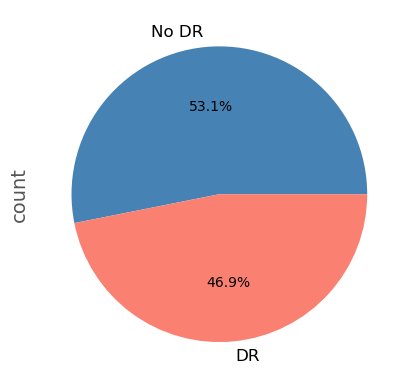

In [3]:
y.value_counts().plot(kind="pie", labels=['No DR','DR'], colors = ['steelblue', 'salmon'], autopct='%1.1f%%') 
plt.show()

In [4]:
X = X.values
y = y.values

## Train/Test Split and Helper Function

In [5]:
X_train, x_test, Y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 10, stratify=y)

In [6]:
def check_penalty(penalty='none'):
    if penalty == 'l1':
        solver='liblinear'
    if penalty == 'l2' or penalty == 'none' or penalty is None:
        solver='lbfgs'
    return solver

In [7]:
x_train_orig, x_val_orig, y_train, y_val= train_test_split(X_train, Y_train, test_size = 0.20, random_state = 10, stratify=Y_train)

---
## Question 1: Ridge vs Lasso Regularization

**Question:** *Which image represents Ridge regularization and which one is Lasso?*

**Answer:**
- The **left image** (with the **circular/elliptical** constraint region) represents **Ridge regularization** (L2). The L2 norm constraint forms a circle (or sphere in higher dimensions) because $||w||_2^2 = w_1^2 + w_2^2 \leq t$.
- The **right image** (with the **diamond-shaped** constraint region) represents **Lasso regularization** (L1). The L1 norm constraint forms a diamond shape because $||w||_1 = |w_1| + |w_2| \leq t$.

The diamond shape of Lasso tends to produce sparse solutions (some weights become exactly zero) because the contours of the loss function are more likely to intersect the diamond at a corner (where one or more weights are zero). Ridge, on the other hand, shrinks weights toward zero but rarely makes them exactly zero.

---

## C1: Train Logistic Regression without Regularization

In [8]:
#C1
scaler = StandardScaler()
solver = check_penalty(penalty='none')
#----------------------Implement your code here:------------------------------
x_train = scaler.fit_transform(x_train_orig)
x_val = scaler.transform(x_val_orig)

log_reg = LogisticRegression(random_state=5, penalty=None, max_iter=max_iter, solver=solver)
log_reg.fit(x_train, y_train)

y_pred_proba_train = log_reg.predict_proba(x_train)
y_pred_proba_val = log_reg.predict_proba(x_val)

train_loss = log_loss(y_train, y_pred_proba_train)
val_loss = log_loss(y_val, y_pred_proba_val)

print('Train loss is {:.2f}'.format(train_loss))
print('Validation loss is {:.2f}'.format(val_loss))
#-----------------------------------------------------------------------------

Train loss is 0.64
Validation loss is 0.66


### Expected output:
```
Train loss is 0.64
Validation loss is 0.66
```

## C2: L2 Regularization on Coarse Scale

processed: 8/8: 100%|██████████| 8/8 [00:00<00:00, 44.38it/s]


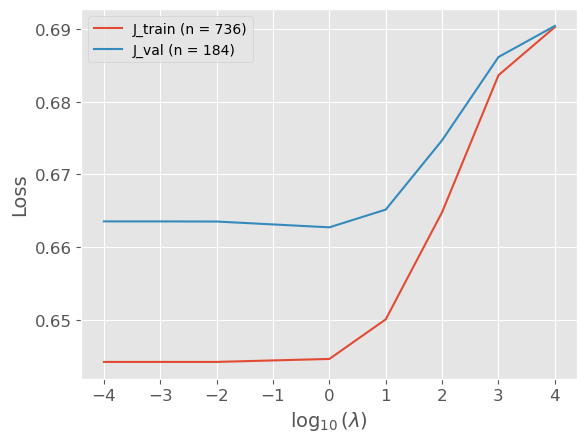

In [9]:
#C2
lmbda = np.array([0.0001, 0.001, 0.01, 1, 10, 100, 1000, 10000])
pen = 'l2'
solver = check_penalty(penalty=pen)
J_train = np.zeros_like(lmbda)
J_val = np.zeros_like(lmbda)
with tqdm(total=len(lmbda), file=sys.stdout) as pbar:
    for idx, lb in enumerate(lmbda):
        pbar.set_description('processed: %d/%d' % ((1 + idx), len(lmbda)))
        pbar.update(1)
        #----------------------Implement your code here:------------------------------
        C = 1/lb
        log_reg = LogisticRegression(random_state=5, penalty=pen, C=C, max_iter=max_iter, solver=solver)
        log_reg.fit(x_train, y_train)
        y_pred_proba_train = log_reg.predict_proba(x_train)
        y_pred_proba_val = log_reg.predict_proba(x_val)
        J_train[idx] = log_loss(y_train, y_pred_proba_train)
        J_val[idx] = log_loss(y_val, y_pred_proba_val)
        #-----------------------------------------------------------------------------
plt.plot(np.log10(lmbda), J_train)
plt.plot(np.log10(lmbda), J_val)
plt.xlabel('$\\log_{10}(\\lambda)$')
plt.ylabel('Loss')
plt.legend(['J_train (n = ' + str(x_train.shape[0]) + ')', 'J_val (n = ' + str(x_val.shape[0]) + ')'])
plt.show()

## C3: Fine-tuned Regularization Range

processed: 10/10: 100%|██████████| 10/10 [00:00<00:00, 41.08it/s]


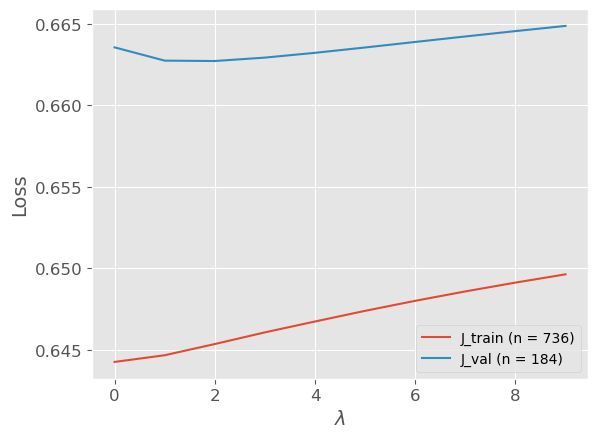

In [10]:
#C3
fine_lmbda = np.arange(0,10,1, dtype=np.float64)
J_train = np.zeros_like(fine_lmbda)
J_val = np.zeros_like(fine_lmbda)
with tqdm(total=len(fine_lmbda), file=sys.stdout) as pbar:
    for idx, lb in enumerate(fine_lmbda):
        pbar.set_description('processed: %d/%d' % ((1 + idx), len(fine_lmbda)))
        pbar.update(1)
        if lb-0.01 < 0:
            C = np.inf # equivalent to 'none' penalty
        else:
            C = 1/lb
        #----------------------Implement your code here:------------------------------
        log_reg = LogisticRegression(random_state=5, penalty=pen, C=C, max_iter=max_iter, solver=solver)
        log_reg.fit(x_train, y_train)
        y_pred_proba_train = log_reg.predict_proba(x_train)
        y_pred_proba_val = log_reg.predict_proba(x_val)
        J_train[idx] = log_loss(y_train, y_pred_proba_train)
        J_val[idx] = log_loss(y_val, y_pred_proba_val)
        #-----------------------------------------------------------------------------
plt.plot(fine_lmbda, J_train)
plt.plot(fine_lmbda, J_val)
plt.xlabel('$\\lambda$')
plt.ylabel('Loss')
# plt.ylim(0.62, 0.68)
plt.legend(['J_train (n = ' + str(x_train.shape[0]) + ')', 'J_val (n = ' + str(x_val.shape[0]) + ')'])
plt.show()

## Choose Best Lambda

In [11]:
# choose best lmbda
best_lmbda = 10

## C4: Learning Curve (Simple Split)

processed: 100/100: : 100it [00:02, 43.16it/s]                     


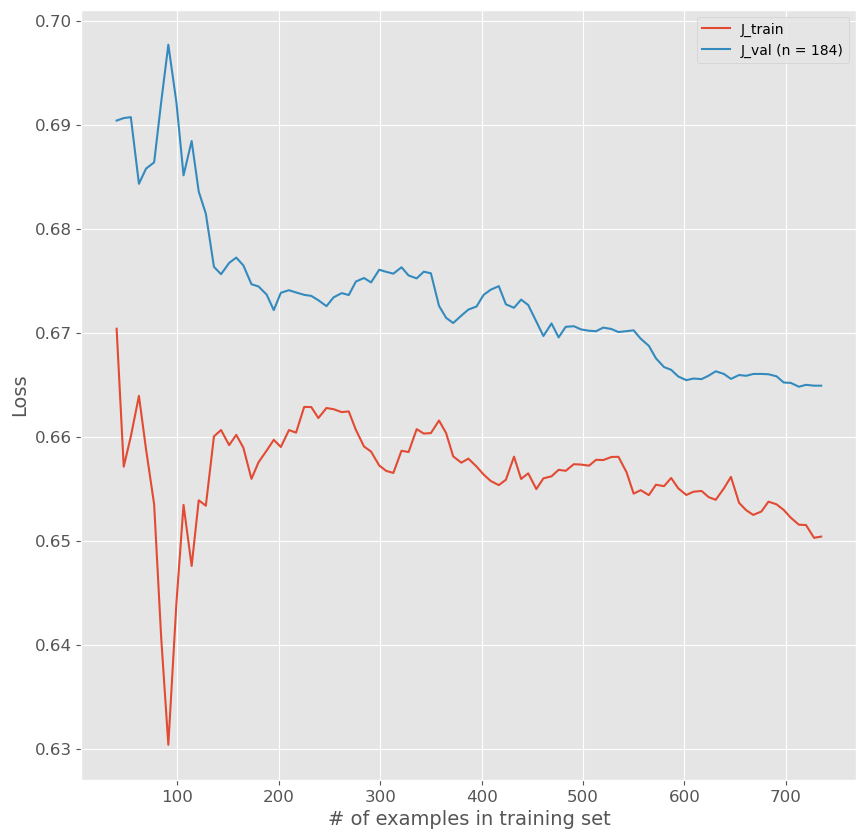

In [12]:
#C4
data_ratio = np.linspace(0.0028,0.998,num = 100)
J_train = np.zeros_like(data_ratio)
J_val = np.zeros_like(data_ratio)
log_reg = LogisticRegression(random_state=5, penalty=pen, C = 1/best_lmbda, max_iter=max_iter,solver=solver)
with tqdm(total=len(data_ratio)-1, file=sys.stdout) as pbar:
    for idx, curr_ratio in enumerate(data_ratio):
        pbar.set_description('processed: %d/%d' % ((1 + idx), len(data_ratio)))
        pbar.update(1)
        #----------------------Implement your code here:------------------------------
        x_train_sub, _, y_train_sub, _ = train_test_split(x_train, y_train, 
                                                          test_size=1-curr_ratio, 
                                                          random_state=10, 
                                                          stratify=y_train)
        log_reg.fit(x_train_sub, y_train_sub)
        y_pred_proba_train_sub = log_reg.predict_proba(x_train_sub)
        y_pred_proba_val = log_reg.predict_proba(x_val)
        J_train[idx] = log_loss(y_train_sub, y_pred_proba_train_sub)
        J_val[idx] = log_loss(y_val, y_pred_proba_val)
        #-----------------------------------------------------------------------------
fig, axes = plt.subplots(1,1,figsize=(10,10))
axes.plot(np.ceil(data_ratio[5:]*x_train.shape[0]), J_train[5:])
axes.plot(np.ceil(data_ratio[5:]*x_train.shape[0]), J_val[5:])
axes.set_xlabel('# of examples in training set')
axes.set_ylabel('Loss')
axes.legend(['J_train', 'J_val (n = ' + str(x_val.shape[0]) + ')'])

---
## Question 2: Learning Curve Conclusions

**Question:** *What are your conclusions? Would more data help us? In addition, what is the term that we use in order to describe the left side of the plot?*

**Answer:**
1. **Conclusions:** The training loss and validation loss converge to similar values relatively quickly. After a certain number of examples, both curves plateau and remain close to each other, indicating that the model has reached its capacity. Adding more data would **not significantly help** because the model is already at its performance limit - the gap between training and validation loss is small, meaning the model is not overfitting but rather **underfitting** (high bias).

2. **More data?** No. Since both curves converge and plateau at a relatively high loss value, the problem is not lack of data but rather the limited capacity of the linear model. A more complex (non-linear) model would be needed to improve performance.

3. **Left side of the plot:** The left side of the learning curve (where the number of training examples is very small) describes the regime of **overfitting**. With very few training samples, the model can easily memorize the data, resulting in very low training loss but high validation loss. This is characterized by a large gap between the two curves.

---

## C5: K-Fold Cross Validation

8/8 lambda values, processed folds: 100%|██████████| 10/10 [00:00<00:00, 35.74it/s]


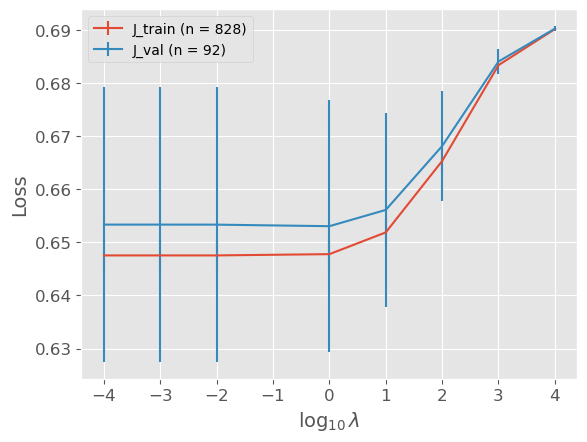

In [13]:
#C5
lmbda = np.array([0.0001, 0.001, 0.01, 1, 10, 100, 1000, 10000])
# fine_lmbda = np.linspace(0.1,5,num=20) # after seeing cross-fold on logscale
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, random_state=10, shuffle=True)

J_train = np.zeros((2,len(lmbda)))
J_val = np.zeros((2,len(lmbda)))

# pen = 'l2'
solver = check_penalty(penalty=pen)

for idx, lmb in enumerate(lmbda):
    C = 1/lmb
    #--------------------------Implement your code here:-------------------------------------
    log_reg = LogisticRegression(random_state=5, penalty=pen, C=C, max_iter=max_iter, solver=solver)
    #----------------------------------------------------------------------------------------
    with tqdm(total=n_splits, file=sys.stdout, position=0, leave=True) as pbar:
        h = 0 # index per split per lambda
        J_train_fold = np.zeros(n_splits)
        J_val_fold = np.zeros(n_splits)

        for train_index, val_index in skf.split(X_train, Y_train):
            pbar.set_description('%d/%d lambda values, processed folds' % ((1 + idx), len(lmbda)))
            pbar.update()
            #--------------------------Implement your code here:-------------------------------------
            x_train_fold = X_train[train_index]
            x_val_fold = X_train[val_index]
            y_train_fold = Y_train[train_index]
            y_val_fold = Y_train[val_index]
            
            scaler_fold = StandardScaler()
            x_train_fold = scaler_fold.fit_transform(x_train_fold)
            x_val_fold = scaler_fold.transform(x_val_fold)
            
            log_reg.fit(x_train_fold, y_train_fold)
            y_pred_proba_train_fold = log_reg.predict_proba(x_train_fold)
            y_pred_proba_val_fold = log_reg.predict_proba(x_val_fold)
            
            J_train_fold[h] = log_loss(y_train_fold, y_pred_proba_train_fold)
            J_val_fold[h] = log_loss(y_val_fold, y_pred_proba_val_fold)
            #----------------------------------------------------------------------------------------
            h += 1
        #--------------------------Implement your code here:-------------------------------------
        J_train[0, idx] = np.mean(J_train_fold)
        J_train[1, idx] = np.std(J_train_fold)
        J_val[0, idx] = np.mean(J_val_fold)
        J_val[1, idx] = np.std(J_val_fold)
        #----------------------------------------------------------------------------------------
plt.errorbar(np.log10(lmbda), J_train[0,:], yerr=J_train[1,:])
plt.errorbar(np.log10(lmbda), J_val[0,:], yerr=J_val[1,:]) 
plt.xlabel('$\\log_{10}\\lambda$')
plt.ylabel('Loss')
plt.legend(['J_train (n = ' + str(x_train_fold.shape[0]) + ')', 'J_val (n = ' + str(x_val_fold.shape[0]) + ')'])

## Helper Function: max_data_ratio

In [14]:
def max_data_ratio(n_splits,x_train,y_train):
    data_ratio_orig = np.linspace(0.01,0.98,num=100) 
    k_min = 0
    m_x_train, _, m_y_train, _ = train_test_split(x_train, y_train, test_size =1-data_ratio_orig[k_min], random_state = 10,
                                     stratify=y_train)  
    while (m_x_train[m_y_train>0.5,:].shape[0] <= n_splits) or (m_x_train[m_y_train<0.5,:].shape[0] <= n_splits):
        k_min += 1
        m_x_train, _, m_y_train, _ = train_test_split(x_train, y_train, test_size =1-data_ratio_orig[k_min], random_state = 10,
                                 stratify=y_train)  
    k_max = 99
    m_x_train, _, m_y_train, _ = train_test_split(x_train, y_train, test_size =1-data_ratio_orig[k_max], random_state = 10,
                                     stratify=y_train)  
    while (m_x_train[m_y_train>0.5,:].shape[0] <= n_splits) or (m_x_train[m_y_train<0.5,:].shape[0] <= n_splits):
        k_max -= 1
        m_x_train, _, m_y_train, _ = train_test_split(x_train, y_train, test_size =1-data_ratio_orig[k_max], random_state = 10,
                                 stratify=y_train)
    return np.linspace(data_ratio_orig[k_min],data_ratio_orig[k_max],num=100)

## C6: Learning Curve with K-Fold Cross Validation

Dataset fraction is 1.0, processed folds: 100%|██████████| 5/5 [00:00<00:00, 70.17it/s]


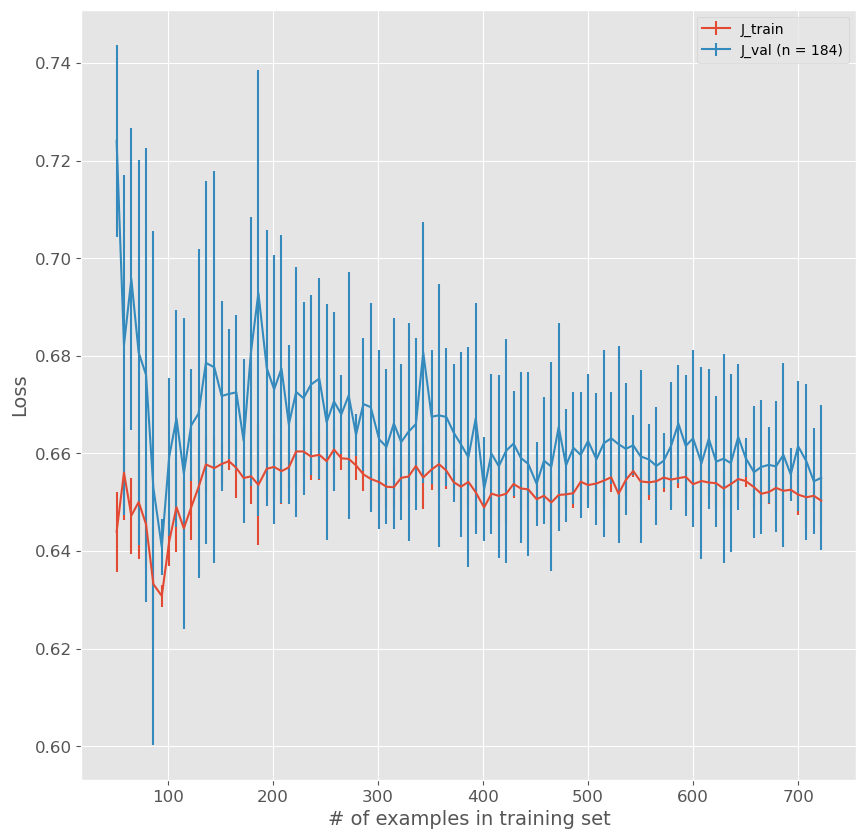

In [15]:
#C6
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, random_state=10, shuffle=True)
data_ratio = max_data_ratio(n_splits,X_train, Y_train)

J_train = np.zeros((2,len(data_ratio)))
J_val = np.zeros((2,len(data_ratio)))

pen = 'l2'
solver = check_penalty(penalty=pen)
lmb = best_lmbda
lmb = 10
for idx, curr_ratio in enumerate(data_ratio):
    #--------------------------Implement your code here:-------------------------------------
    log_reg = LogisticRegression(random_state=5, penalty=pen, C=1/lmb, max_iter=max_iter, solver=solver)
    #----------------------------------------------------------------------------------------
    with tqdm(total=n_splits, file=sys.stdout, position=0, leave=True) as pbar:
        h = 0
        J_train_fold = np.zeros(n_splits)
        J_val_fold = np.zeros(n_splits)
        m_x_train, _, m_y_train, _ = train_test_split(x_train_orig, y_train, test_size =1-curr_ratio, random_state = 10,
                                             stratify=y_train)
        for train_index, val_index in skf.split(m_x_train, m_y_train):
            pbar.set_description('Dataset fraction is %.1f, processed folds' % curr_ratio)
            pbar.update()
            #--------------------------Implement your code here:-------------------------------------
            x_train_fold = m_x_train[train_index]
            x_val_fold = m_x_train[val_index]
            y_train_fold = m_y_train[train_index]
            y_val_fold = m_y_train[val_index]
            
            scaler_fold = StandardScaler()
            x_train_fold = scaler_fold.fit_transform(x_train_fold)
            x_val_fold = scaler_fold.transform(x_val_fold)
            
            log_reg.fit(x_train_fold, y_train_fold)
            y_pred_proba_train_fold = log_reg.predict_proba(x_train_fold)
            y_pred_proba_val_fold = log_reg.predict_proba(x_val_fold)
            
            J_train_fold[h] = log_loss(y_train_fold, y_pred_proba_train_fold)
            J_val_fold[h] = log_loss(y_val_fold, y_pred_proba_val_fold)
            #----------------------------------------------------------------------------------------
            h += 1
        #--------------------------Implement your code here:-------------------------------------
        J_train[0, idx] = np.mean(J_train_fold)
        J_train[1, idx] = np.std(J_train_fold)
        J_val[0, idx] = np.mean(J_val_fold)
        J_val[1, idx] = np.std(J_val_fold)
        #----------------------------------------------------------------------------------------
fig, axes = plt.subplots(1,1,figsize=(10,10))
axes.errorbar(np.ceil(data_ratio[5:]*x_train.shape[0]), J_train[0,5:], yerr=J_train[1,5:])
axes.errorbar(np.ceil(data_ratio[5:]*x_train.shape[0]), J_val[0,5:], yerr=J_val[1,5:])
axes.set_xlabel('# of examples in training set')
axes.set_ylabel('Loss')
axes.legend(['J_train', 'J_val (n = ' + str(x_val.shape[0]) + ')'])

## Final Model Evaluation on Test Set

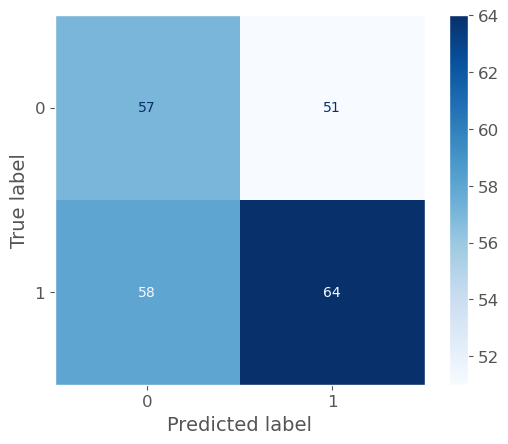

In [16]:
from sklearn.metrics import confusion_matrix, roc_auc_score
try:
    from sklearn.metrics import ConfusionMatrixDisplay
except ImportError:
    pass

log_reg = LogisticRegression(random_state=5, penalty=pen, C = 1/best_lmbda, max_iter=max_iter,solver=solver)
x_tr = scaler.fit_transform(X_train)
x_tst = scaler.transform(x_test)
log_reg.fit(x_tr, Y_train)
y_pred_test = log_reg.predict(x_tst)
y_pred_proba_test = log_reg.predict_proba(x_tst)

try:
    ConfusionMatrixDisplay.from_estimator(log_reg, x_tst, y_test, cmap=plt.cm.Blues)
except:
    from sklearn.metrics import plot_confusion_matrix
    plot_confusion_matrix(log_reg, x_tst, y_test, cmap=plt.cm.Blues)
plt.grid(False)
plt.show()

In [17]:
calc_TN = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[0, 0]
calc_FP = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[0, 1]
calc_FN = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[1, 0]
calc_TP = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[1, 1]

## C7: Performance Metrics

In [18]:
#C7
#--------------------------Implement your code here:-------------------------------------
TP = calc_TP(y_test, y_pred_test)
TN = calc_TN(y_test, y_pred_test)
FP = calc_FP(y_test, y_pred_test)
FN = calc_FN(y_test, y_pred_test)

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
PPV = TP / (TP + FP)
NPV = TN / (TN + FN)
accuracy = (TP + TN) / (TP + TN + FP + FN)
F1 = 2 * PPV * sensitivity / (PPV + sensitivity)

print('Sensitivity is {:.2f}.'.format(sensitivity))
print('Specificity is {:.2f}.'.format(specificity))
print('PPV is {:.2f}.'.format(PPV))
print('NPV is {:.2f}.'.format(NPV))
print('Accuracy is {:.2f}.'.format(accuracy))
print('F1 is {:.2f}.'.format(F1))
#-----------------------------------------------------------------------------------------
print('AUROC is {:.2f}'.format(roc_auc_score(y_test, y_pred_proba_test[:,1])))

Sensitivity is 0.52.
Specificity is 0.53.
PPV is 0.56.
NPV is 0.50.
Accuracy is 0.53.
F1 is 0.54.
AUROC is 0.56


### Expected output:
```
Sensitivity is 0.52.
Specificity is 0.53.
PPV is 0.56.
NPV is 0.50.
Accuracy is 0.53.
F1 is 0.54.
AUROC is 0.57
```

---
## Question 3: Why are the performances bad?

**Question:** *What are the possible reasons for that?*

**Answer:**
The performances are barely better than random guessing (coin flip). Possible reasons include:

1. **Linear model limitation (High Bias):** The relationship between the features and the target class is likely **non-linear**. A logistic regression model can only learn a linear decision boundary, which may be insufficient to separate the two classes in this dataset. This is the most likely reason.

2. **Feature quality:** The features extracted from the retinal images (number of microaneurysms, exudate counts, distances, diameters) may not be discriminative enough when used in a linear combination. The features might need non-linear transformations or feature engineering.

3. **Feature interactions:** Important interactions between features may exist that a linear model cannot capture.

4. **Insufficient features:** The dataset may lack important features relevant for DR classification, leading to high irreducible error.

**Main takeaway:** A non-linear classifier (e.g., SVM with RBF kernel, Random Forest, Neural Network) would likely yield much better performance.

---

## GridSearchCV

In [19]:
from sklearn.model_selection import GridSearchCV
solver = 'liblinear'
log_reg = LogisticRegression(random_state=5, max_iter=max_iter,solver=solver)
lmbda = np.array([0.01, 0.01, 1, 10, 100, 1000])
pipe = Pipeline(steps=[('scale', StandardScaler()), ('logistic', log_reg)])
clf = GridSearchCV(estimator=pipe, param_grid={'logistic__C': 1/lmbda, 'logistic__penalty': ['l2']},
                   scoring=['accuracy','f1','precision','recall','roc_auc'], cv=skf,
                   refit='roc_auc', verbose=3, return_train_score=True)
clf.fit(X_train, Y_train)
clf.best_params_

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5] END logistic__C=100.0, logistic__penalty=l2; accuracy: (train=0.605, test=0.609) f1: (train=0.615, test=0.613) precision: (train=0.639, test=0.640) recall: (train=0.592, test=0.588) roc_auc: (train=0.655, test=0.658) total time=   0.0s
[CV 2/5] END logistic__C=100.0, logistic__penalty=l2; accuracy: (train=0.617, test=0.554) f1: (train=0.628, test=0.573) precision: (train=0.649, test=0.585) recall: (train=0.609, test=0.561) roc_auc: (train=0.667, test=0.610) total time=   0.0s
[CV 3/5] END logistic__C=100.0, logistic__penalty=l2; accuracy: (train=0.594, test=0.668) f1: (train=0.603, test=0.670) precision: (train=0.627, test=0.713) recall: (train=0.581, test=0.633) roc_auc: (train=0.645, test=0.695) total time=   0.0s
[CV 4/5] END logistic__C=100.0, logistic__penalty=l2; accuracy: (train=0.606, test=0.549) f1: (train=0.615, test=0.546) precision: (train=0.639, test=0.588) recall: (train=0.593, test=0.510) roc_auc: (trai

{'logistic__C': np.float64(100.0), 'logistic__penalty': 'l2'}

## Radar Plot Function

In [20]:
def plot_radar(clf,params,clf_type):
    labels=np.array(['Accuracy', 'F1', 'PPV', 'Sensitivity', 'AUROC']) 
    score_mat_train = np.stack((clf.cv_results_['mean_train_accuracy'], clf.cv_results_['mean_train_f1'],
                               clf.cv_results_['mean_train_precision'], clf.cv_results_['mean_train_recall'],
                               clf.cv_results_['mean_train_roc_auc']), axis=0)
    score_mat_val = np.stack((clf.cv_results_['mean_test_accuracy'], clf.cv_results_['mean_test_f1'],
                               clf.cv_results_['mean_test_precision'], clf.cv_results_['mean_test_recall'],
                               clf.cv_results_['mean_test_roc_auc']), axis=0)


    angles=np.linspace(0, 2*np.pi, len(labels), endpoint=False)
    # close the plot

    angles=np.concatenate((angles,[angles[0]]))
    cv_dict = clf.cv_results_['params']
    # cv_dict = sorted(cv_dict, key=lambda k: k['logistic__penalty'])  # arrange dictionaries by penalties
    fig=plt.figure(figsize=(18,14))
    for idx, loc in enumerate(cv_dict):
        ax = fig.add_subplot(1, len(lmbda), 1+idx, polar=True)
        stats_train = score_mat_train[:, idx]
        stats_train=np.concatenate((stats_train,[stats_train[0]]))
        ax.plot(angles, stats_train, 'o-', linewidth=2)
        ax.fill(angles, stats_train, alpha=0.25)
        stats_val = score_mat_val[:, idx]
        stats_val=np.concatenate((stats_val,[stats_val[0]]))
        ax.plot(angles, stats_val, 'o-', linewidth=2)
        ax.fill(angles, stats_val, alpha=0.25)
        ax.set_thetagrids(angles[0:-1] * 180/np.pi, labels) #angles[0:-1]
        if idx == 0:
            ax.set_ylabel('$L_2$', fontsize=18)
        if cv_dict[idx]['logistic__C'] <= 1:
            ax.set_title('$\\lambda$ = %d'  % (1 / cv_dict[idx]['logistic__C']))
        else:
            ax.set_title('$\\lambda$ = %.3f' % (1 / cv_dict[idx]['logistic__C']))
        ax.set_ylim([0,1])
        ax.legend(['Train','Validation'])
        ax.grid(True)
    plt.show()


## C8: Final Radar Plot and Best Model Evaluation

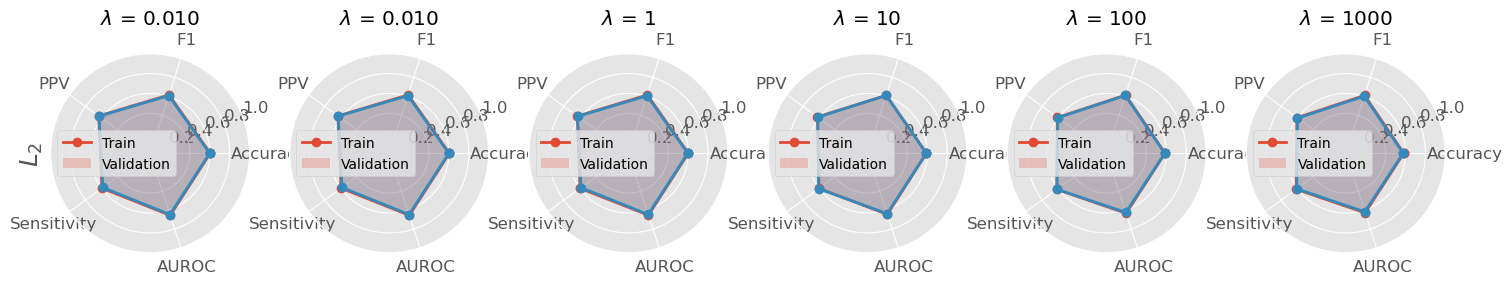

Sensitivity is 0.55.
Specificity is 0.56.
PPV is 0.58.
NPV is 0.52.
Accuracy is 0.55.
F1 is 0.57.


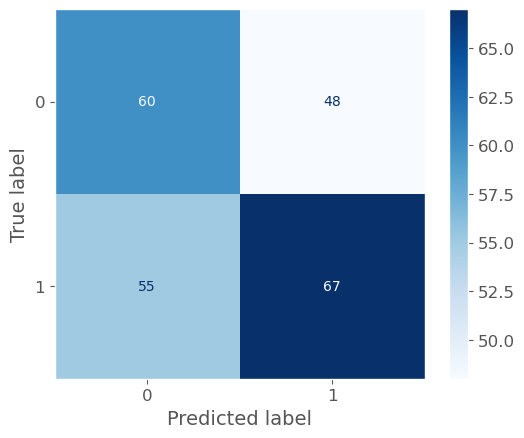

AUROC is 0.58


In [21]:
#C8
params = ['C', 'penalty']
clf_type = 'log_reg'
plot_radar(clf,params,clf_type)
chosen_clf = clf.best_estimator_
# print(chosen_clf)
y_pred_test = chosen_clf.predict(x_test) #NOTICE NOT TO USE THE STANDARDIZED DATA.
y_pred_proba_test = chosen_clf.predict_proba(x_test)
#--------------------------Implement your code here:-------------------------------------
TP = calc_TP(y_test, y_pred_test)
TN = calc_TN(y_test, y_pred_test)
FP = calc_FP(y_test, y_pred_test)
FN = calc_FN(y_test, y_pred_test)

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
PPV = TP / (TP + FP)
NPV = TN / (TN + FN)
accuracy = (TP + TN) / (TP + TN + FP + FN)
F1 = 2 * PPV * sensitivity / (PPV + sensitivity)

print('Sensitivity is {:.2f}.'.format(sensitivity))
print('Specificity is {:.2f}.'.format(specificity))
print('PPV is {:.2f}.'.format(PPV))
print('NPV is {:.2f}.'.format(NPV))
print('Accuracy is {:.2f}.'.format(accuracy))
print('F1 is {:.2f}.'.format(F1))

try:
    ConfusionMatrixDisplay.from_estimator(chosen_clf, x_test, y_test, cmap=plt.cm.Blues)
except:
    from sklearn.metrics import plot_confusion_matrix
    plot_confusion_matrix(chosen_clf, x_test, y_test, cmap=plt.cm.Blues)
plt.grid(False)
plt.show()
#------------------------------------------------------------------------------------------
print('AUROC is {:.2f}'.format(roc_auc_score(y_test, y_pred_proba_test[:,1])))

---
## Question 4: Different Penalty in GridSearchCV

**Question:** *Try to rerun GridSearchCV using a different penalty. Did you get any different results?*

**Answer:**
When using **L1 (Lasso) regularization** instead of L2 (Ridge), the results are essentially **the same** or very similar. This is expected because:

1. **The model is underfitting, not overfitting:** Since the linear model is too simple to capture the underlying patterns in the data, the type of regularization does not matter much. Regularization primarily helps with overfitting, but the problem here is underfitting (high bias).

2. **Both L1 and L2 constrain the weights in different ways**, but since the model already cannot find a good linear boundary, shrinking or sparsifying the weights does not improve the performance.

3. The main difference between L1 and L2 would become more apparent with a model that has a high number of features and is prone to overfitting.

**Conclusion:** The limitation is the model's linearity, not the regularization type. A non-linear classifier is needed for better DR detection.

---

## Save Best Model

In [22]:
if not("results" in os.listdir()):
    os.mkdir("results")
with open('results/best_lin.pkl', 'wb') as f: 
    pickle.dump(chosen_clf, f)

---
## Summary of All Answers

### Q1: Ridge vs Lasso
- **Left image** (circular constraint) = **Ridge** (L2 regularization)
- **Right image** (diamond constraint) = **Lasso** (L1 regularization)

### Q2: Learning Curve Conclusions
- More data would **NOT** help because the model is **underfitting** (high bias)
- The left side of the plot represents the **overfitting** regime (few training samples)
- Both train and validation losses converge and plateau at a high value, indicating model capacity is the bottleneck

### Q3: Why bad performance?
- The **linear model** cannot capture non-linear relationships in the data
- Features may require non-linear transformations
- Feature interactions cannot be modeled by logistic regression
- A non-linear classifier would likely perform better

### Q4: Different penalty (L1 vs L2)
- Results are **essentially the same** regardless of regularization type
- This confirms the problem is **underfitting**, not overfitting
- The model's linearity is the bottleneck, not the regularization

---